# Neural Network classification with PyTorch

*Classification is a problem of predicting whether something is thing or another*

## 1.Make classification data and get it ready

In [ ]:
import sklearn
from sklearn.datasets import make_circles

# Make 100 samples
n_samples = 1000

# Create circles
X,y = make_circles(n_samples, noise=0.03, random_state=42)

len(X), len (y)


(1000, 1000)

In [ ]:
print(f"First 5 samples of X: {X[:5]}")
print(f"First 5 samples of y: {y[:5]}")

First 5 samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y: [1 1 1 1 0]


In [ ]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1":X[:,0],
                        "X2": X[:,1],
                        "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


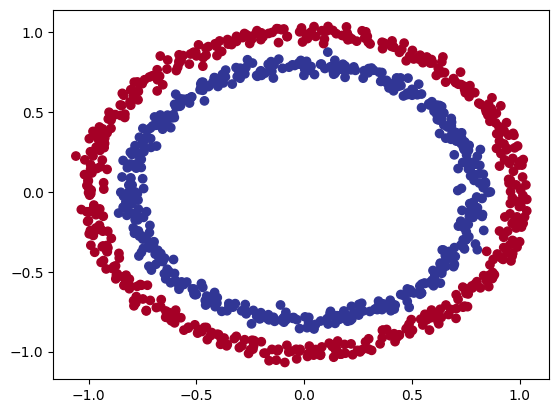

In [ ]:
# Visualize, visuzlize, visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap = plt.cm.RdYlBu)

*Note: the data we are working is ofthen reffered to as a toy dataset (small to experiment but enough to practice the fundamentals)*

### 1.1 Check input and output shapes

In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

In [ ]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of x : {X_sample} and same for y: {y_sample}")
print(f"Shapres for x: {X_sample.shape} and for y: {y_sample.shape}")

Values for one sample of x : [0.75424625 0.23148074] and same for y: 1
Shapres for x: (2,) and for y: ()


### 1.2 Turn data into tensors and create train and test splits

In [ ]:
type(X), X.dtype, y.dtype

(numpy.ndarray, dtype('float64'), dtype('int64'))

### 1.3 Split data into training and test sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size= 0.2,
                                                    random_state=42) #20 % for test and 80 for train
len(X_train), len(X_test), len(y_train), len(y_test)


(800, 200, 800, 200)

## 2.Bulding a model

1. Setup device agnostic code
2. Construct a model (nn.Module)
3. Define a loss function and optimizer
4. Create a training test loop

 ### 2.1 Setup agnostic code

In [ ]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

 ### 2.2 Construct a model

In [ ]:
# 1. Construct a model that subclasses nn
class CircleModelv0(nn.Module):
  def __init__(self):
    super().__init__()
    # 2. Create 2 nn.Linear layerrs capable oof handling the shapes of the data
    self.layer_1 = nn.Linear(in_features=2,out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)
   # 3. Overwrite forward method
  def forward(self,x):
    return self.layer_2(self.layer_1(x)) # x => layer_1 => layer_2 => output


    # 4. Instantiate an instance of our model and send it to the target device
model_0 = CircleModelv0().to(device)
model_0


CircleModelv0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
# Let's replicate the model above using nn.Sequantial
model_0 = nn.Sequential(nn.Linear(in_features=2,out_features=5),
                        nn.Linear(in_features=5,out_features=1)).to(device)

model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]])),
             ('0.bias', tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370])),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]])),
             ('1.bias', tensor([-0.1213]))])

 ### 2.3 Make predicitions

 ### 2.4 Setup loss function & optimizer
1. *For ***regression**** might use MAE OR MSE (mean absolute error or mean squared error)
2. *For ***classification**** might use binary cross entropy or categorical cross entropy (cross entropy)
3. *For ***optimizers****, two of the most common and useful are SGD and Adam

***Resources:***
> Logit definition: https://stackoverflow.com/questions/41455101/what-is-the-meaning-of-the-word-logits-in-tensorflow

> Binary cross entropy (BCE): https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html

> For different optimizers: https://docs.pytorch.org/docs/stable/optim.html

> Sigmoid activation functions: https://docs.pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html

> Accuracy: https://docs.pytorch.org/ignite/generated/ignite.metrics.Accuracy.html

In [ ]:
# Convert from numpy.arr to tensor if not already a tensor
import numpy as np # Ensure numpy is imported for type checking

if isinstance(X_test, np.ndarray):
    X_test = torch.from_numpy(X_test).type(torch.float)
if isinstance(y_test, np.ndarray):
    y_test = torch.from_numpy(y_test).type(torch.float)
if isinstance(X_train, np.ndarray):
    X_train = torch.from_numpy(X_train).type(torch.float)
if isinstance(y_train, np.ndarray):
    y_train = torch.from_numpy(y_train).type(torch.float)


In [ ]:
# Make predictions
with torch.inference_mode():
  untrained_preds = model_0(X_test).to(device)

print(f"Length of predictions: {len(untrained_preds)}, shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, shape: {X_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of predictions: 200, shape: torch.Size([200, 1])
Length of test samples: 200, shape: torch.Size([200, 2])

First 10 predictions:
tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]])

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [ ]:
# Setup the loss function

#loss_fn = nn.BCELoss() # requires inputs to have gone through the sigmoid activation function prior to input yo BCELoss:
# nn.Sequential(
#     nn.Sigmoid(),
#     nn.BCELoss()
# )

# So instead of upper BCELoss() we should use BCEWithLogitsLoss with sigmoid activation built in
loss_fn = nn.BCEWithLogitsLoss()

# Setup optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.1)


In [ ]:
# Calculate accuracy - out of 100 examples, what percantage does our model get right?
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

## 3.Train the model

*Steps:*
1. ***Forward pass***
2. ***Calculate the loss***
3. ***Zero gradients***
4. ***Loss backward (backpropagation)***
5. ***Step the optimizer (gradient descent)***


*Going from raw logits -> prediction probabilities -> prediction labels*

We can convert these ***logits*** into prediction probabilities by passing them to some kind of activation function (sigmoid for binary crossentropy and softmax for multicalss calssification)

Then we can convert our model's prediction probabilities to ***prediction labels** by either rounding them or taking them to argmax


In [ ]:
# View the first 5 outputs of the forward pass on test data

with torch.inference_mode():
  y_logits = model_0(X_test[:5]).to(device)
y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]])

In [ ]:
# Use the sigmoid activation function on our model logits to turn them into prediction probabilities

y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]])

For our prediction probabiliities values we need to perform a range-style rounding opn them:
* 'y_pred_probs' >= 0.5 => (class 1)
* 'y_pred_probs' <= 0.5 => (class 0)


In [ ]:
torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]])

In [ ]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)

#In full (logits -> pred probs -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test).to(device)[:5]))

 # Check for equality
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))

# Get rid of extra dimension again
y_preds.squeeze()


tensor([True, True, True, True, True])


tensor([0., 0., 1., 0., 1.])

### 3.1 Building a training and testing loop

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 300

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Train loop
for epoch in range(epochs):
  ## Training
  model_0.train()

  # 1. Forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # turn logit -> pred probs -> labels

  # 2. Calculate the loss/accuracy
  loss = loss_fn(y_logits,y_train)

  acc = accuracy_fn(y_true=y_train,y_pred=y_pred)

  # 3. Optimizer zero graph
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step (gradient descent)\
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. Calculate test loss function
    test_loss = loss_fn(test_logits,y_test)
    test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)

    # Print out whats happening
    if epoch % 10 == 0:
       print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")



Epoch: 0 | Loss: 0.69796 | Acc: 5.2e+01% | Test loss: 0.69440 | Test acc: 58.00%
Epoch: 10 | Loss: 0.69590 | Acc: 5.1e+01% | Test loss: 0.69305 | Test acc: 53.00%
Epoch: 20 | Loss: 0.69490 | Acc: 5.2e+01% | Test loss: 0.69254 | Test acc: 49.50%
Epoch: 30 | Loss: 0.69435 | Acc: 5.1e+01% | Test loss: 0.69236 | Test acc: 49.50%
Epoch: 40 | Loss: 0.69401 | Acc: 5.1e+01% | Test loss: 0.69232 | Test acc: 51.00%
Epoch: 50 | Loss: 0.69378 | Acc: 5e+01% | Test loss: 0.69234 | Test acc: 50.00%
Epoch: 60 | Loss: 0.69362 | Acc: 5e+01% | Test loss: 0.69239 | Test acc: 51.50%
Epoch: 70 | Loss: 0.69351 | Acc: 5e+01% | Test loss: 0.69246 | Test acc: 51.00%
Epoch: 80 | Loss: 0.69342 | Acc: 5e+01% | Test loss: 0.69254 | Test acc: 50.00%
Epoch: 90 | Loss: 0.69336 | Acc: 5e+01% | Test loss: 0.69262 | Test acc: 53.00%
Epoch: 100 | Loss: 0.69331 | Acc: 4.9e+01% | Test loss: 0.69271 | Test acc: 53.00%
Epoch: 110 | Loss: 0.69327 | Acc: 5e+01% | Test loss: 0.69279 | Test acc: 54.00%
Epoch: 120 | Loss: 0.69324 

### 3.2 Make predictions and evaluate the model

Our model is not learning anything, so to inspect it - make some predictions and make them visual

To do so we are going to import function called `plot_decision_boundary()`-

In [ ]:
# Download and save helper_functions.py
import requests
from pathlib import Path

github_url = "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py"

# Download helper functions in PyTorch repo if it isnt already downloaded

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download..")
else:
  print("Download helper_functions_py")
  request = requests.get(url=github_url)
  with open ("helper_functions.py","wb") as f:
    f.write(request.content)

from helper_functions import plot_decision_boundary ,plot_predictions

helper_functions.py already exists, skipping download..


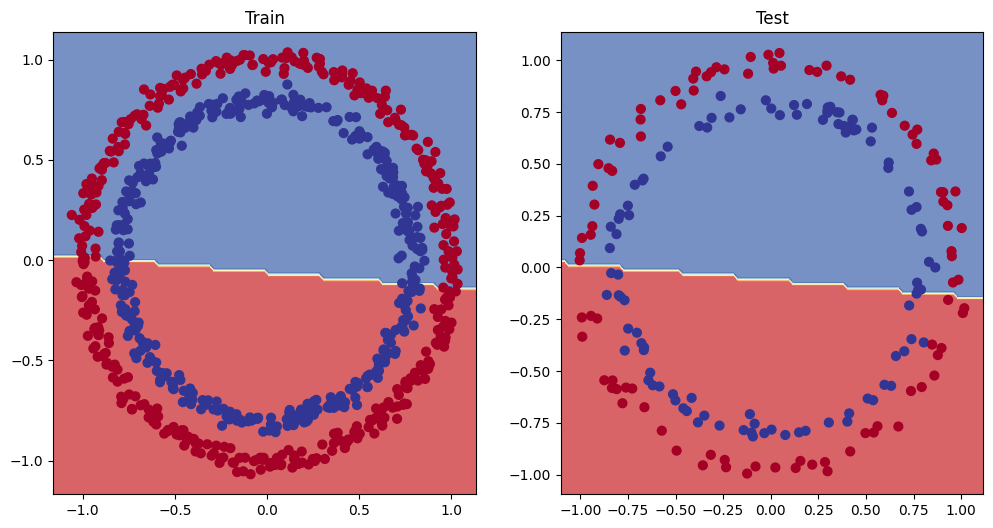

In [ ]:
# Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)





## 4.Improving a model

* Add more layers - give the model more chances to learn about patterns in data
* Add more hidden units - go from 5 hidden units to 10 hiddent units
* Fit for longer
* Changing the activation fucntion
* Change the learning rate

Because these options are all values we can chage them (hyperparameters)


*Let's try and improve our model by:*
* Adding more hidden units: 5 -> 10
* Increase the number of layers : 2 -> 3
* Increase the number of epochs: 100 -> 1000

In [ ]:
class CircleModelv1(nn.Module):
  def __init__(self):
    super().__init__()
    self .layer_1 = nn.Linear(in_features=2,out_features=10)
    self.layer_2 = nn.Linear(in_features=10,out_features=10)
    self.layer_3 = nn.Linear(in_features=10,out_features=1)

  def forward(self,x):
    # Passing the data into the layers
    # z = self.layer_1(x)
    # z = self.layer_2(z)
    # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x))) # this way of writing operations leverage speeds up where possible behind the scenes

model_1 = CircleModelv1().to(device)
model_1



CircleModelv1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Creata a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),lr=0.1)


In [ ]:
# Write and training the evaluation loop for model 1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train for longer
epochs = 1000

# Put data on the target device
X_train,y_train = X_train.to(device), y_train.to(device)
X_test,y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  # Turn the model in train mode
  model_1.train()

  # 1. Forward pass
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> pred probabilities -> prediction labels

  # 2. Loss & Accuracy
  loss = loss_fn(y_logits,y_train)
  acc = accuracy_fn(y_true =y_train, y_pred=y_pred)

  # 3. Optimizer zero graph
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ### Testing
  model_1.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    # 2. Calculate the loss
    test_loss = loss_fn(test_logits,y_test)
    test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)


    # Print what's happening
    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss} | Acc: {acc}% | Test loss: {test_loss} | Test Acc: {test_acc}%")



Epoch: 0 | Loss: 0.6939550638198853 | Acc: 50.875% | Test loss: 0.6926146149635315 | Test Acc: 51.0%
Epoch: 100 | Loss: 0.6930477619171143 | Acc: 50.375% | Test loss: 0.6937904357910156 | Test Acc: 48.0%
Epoch: 200 | Loss: 0.692986011505127 | Acc: 51.125% | Test loss: 0.6943727135658264 | Test Acc: 46.0%
Epoch: 300 | Loss: 0.6929805278778076 | Acc: 51.625% | Test loss: 0.6945767998695374 | Test Acc: 45.0%
Epoch: 400 | Loss: 0.6929798722267151 | Acc: 51.125% | Test loss: 0.6946452260017395 | Test Acc: 46.0%
Epoch: 500 | Loss: 0.6929798722267151 | Acc: 51.0% | Test loss: 0.6946679949760437 | Test Acc: 46.0%
Epoch: 600 | Loss: 0.6929798126220703 | Acc: 51.0% | Test loss: 0.6946756839752197 | Test Acc: 46.0%
Epoch: 700 | Loss: 0.6929798722267151 | Acc: 51.0% | Test loss: 0.6946782469749451 | Test Acc: 46.0%
Epoch: 800 | Loss: 0.6929798722267151 | Acc: 51.0% | Test loss: 0.6946792006492615 | Test Acc: 46.0%
Epoch: 900 | Loss: 0.6929798126220703 | Acc: 51.0% | Test loss: 0.694679319858551 | 

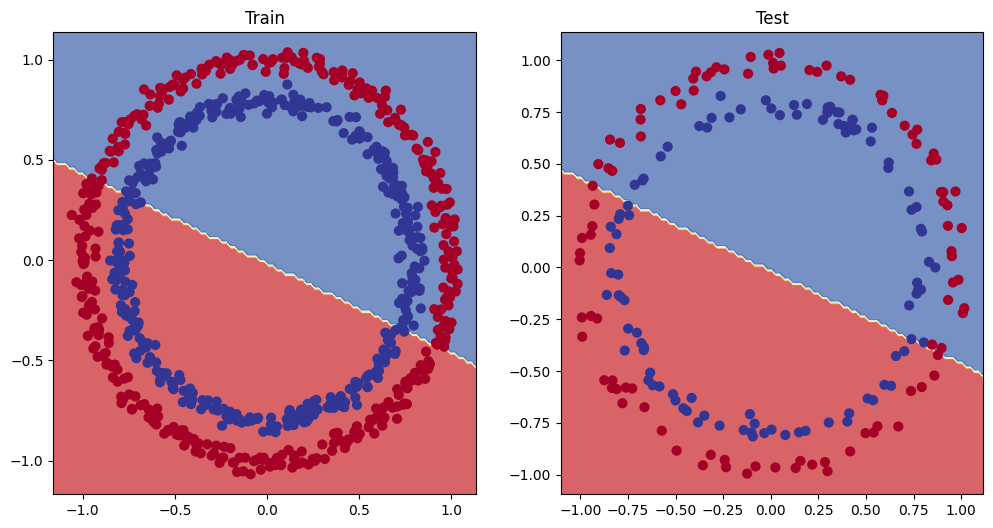

In [ ]:
# Plot the decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,y_test)


### 4.1 Preparing data to see if our model can fit a straight line

*One way to troubleshoot to a larger problem is to test out a smaller one*

In [ ]:
# Create some data
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_regression = torch.arange(start,end,step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

print(len(X_regression))
X_regression[:5], y_regression[:5]


100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [ ]:
# Create a train and test splits
train_split = int(0.8* len(X_regression))

X_train_regression,y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression,y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Check the length of each
len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression)

(80, 80, 20, 20)

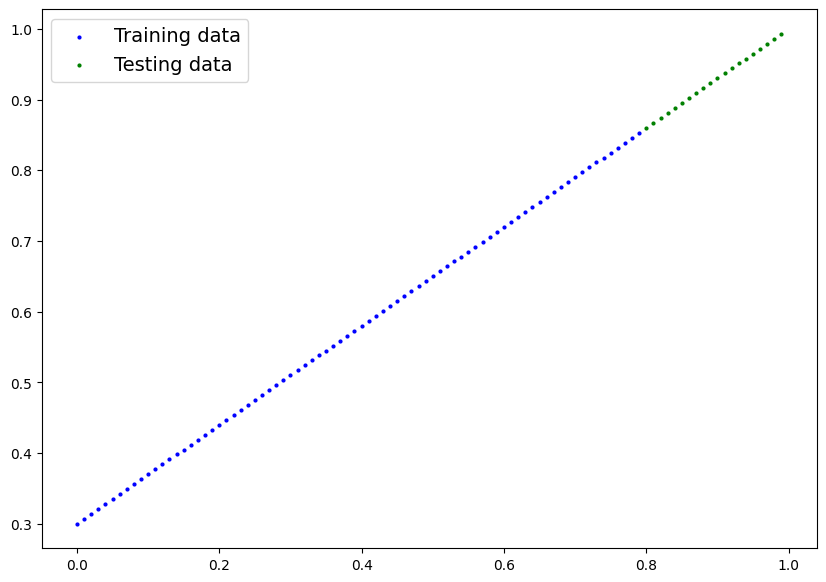

In [ ]:
plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression)

### 4.2 Adjust `model_1` to fit a straight line

In [ ]:
# Same architecture as model_1
model_2 = nn.Sequential(
    nn.Linear(in_features=1,out_features=10),
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10,out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(),lr=0.01)

In [ ]:
# Train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put the date on device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

# Training
for epoch in range(epochs):
  model_2.train()

  # Forward pass
  y_pred = model_2(X_train_regression)

  # Loss
  loss = loss_fn(y_pred,y_train_regression)

  # Optimizer
  optimizer.zero_grad()

  # Loss backward
  loss.backward()

  # Optimizer step
  optimizer.step()

  # Testing
  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test_regression)
    test_loss = loss_fn(test_pred,y_test_regression)

  # Print what's happening
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f}")



Epoch: 0 | Loss: 0.01782 | Test loss: 0.00333
Epoch: 100 | Loss: 0.01674 | Test loss: 0.00317
Epoch: 200 | Loss: 0.01640 | Test loss: 0.00316
Epoch: 300 | Loss: 0.01648 | Test loss: 0.00256
Epoch: 400 | Loss: 0.01648 | Test loss: 0.00323
Epoch: 500 | Loss: 0.01632 | Test loss: 0.00337
Epoch: 600 | Loss: 0.01596 | Test loss: 0.00284
Epoch: 700 | Loss: 0.01458 | Test loss: 0.00244
Epoch: 800 | Loss: 0.01532 | Test loss: 0.00275
Epoch: 900 | Loss: 0.01406 | Test loss: 0.00288


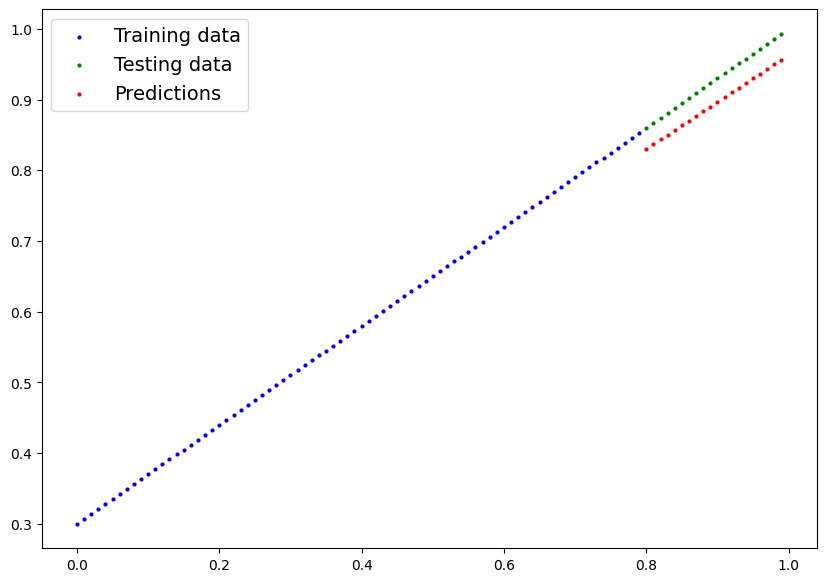

In [ ]:
# Turn on evaluation
model_2.eval()

# Make predictions
with torch.inference_mode():
  y_preds = model_2(X_test_regression)

# Plot datas and predicitons
plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression,
                 predictions=y_preds)

## 5.The missing pice: `non-linearity`

In ML learning terms, an infinite amount of linear and non-linear functions ?

### 5.1 Reacreating non-linear data (red and blue circles)

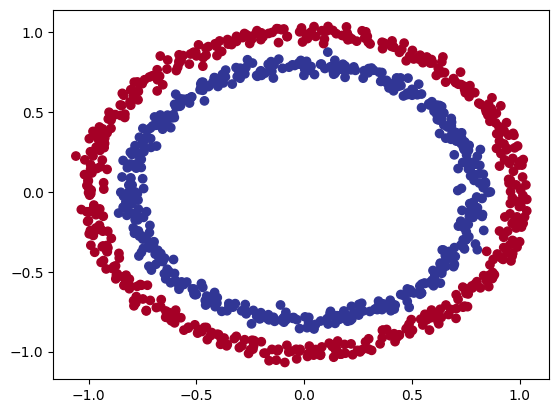

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
n_samples = 1000

X,y = make_circles(n_samples,noise=0.03,random_state=42)

plt.scatter(X[:,0],X[:,1], c=y,cmap = plt.cm.RdYlBu)

In [ ]:
# Convert data to tensors and then to train and test splits
import torch
from sklearn.model_selection import train_test_split

# Turn data into tesnors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

X_train[:5], y_train[:5], X_test[:5], y_test[:5]


(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]),
 tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438]]),
 tensor([1., 0., 1., 0., 1.]))

## 6.Building a model with non-linearity

* Linear = straing lines
* Non-linear = non-straight lines

Artificial neural networks are large combination of linear and non-linear functions that are potentially able to find patterns in given data

In [ ]:
# Build a model with non-linear activation functions
from torch import nn

class CircleModelv2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10,out_features=10)
    self.layer_3 = nn.Linear(in_features=10,out_features=1)
    self.relu = nn.ReLU() # relu is a non-linear activation function

  def forward(self,x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelv2().to(device)
model_3

CircleModelv2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
# Setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(),lr =0.1)

### 6.1 Training a model with non linearity

In [ ]:
# Random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Loop through data
epochs = 1000

for epoch in range(epochs):
  # Training
  model_3.train()

  # 1. Forward pass
  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. Calculate the loss and accuracy
  loss = loss_fn(y_logits,y_train)
  acc = accuracy_fn(y_true=y_train,y_pred=y_pred)

  # 3. Optimizer zero
  optimizer.zero_grad() # reset every epoch (starts fresh)

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()  # gradient descent

  # Testing
  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,y_test)
    test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)

  # Print whats happening
    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test acc {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69295 | Acc: 50.00% | Test Loss: 0.69319 | Test acc 50.00%
Epoch: 100 | Loss: 0.69115 | Acc: 52.88% | Test Loss: 0.69102 | Test acc 52.50%
Epoch: 200 | Loss: 0.68977 | Acc: 53.37% | Test Loss: 0.68940 | Test acc 55.00%
Epoch: 300 | Loss: 0.68795 | Acc: 53.00% | Test Loss: 0.68723 | Test acc 56.00%
Epoch: 400 | Loss: 0.68517 | Acc: 52.75% | Test Loss: 0.68411 | Test acc 56.50%
Epoch: 500 | Loss: 0.68102 | Acc: 52.75% | Test Loss: 0.67941 | Test acc 56.50%
Epoch: 600 | Loss: 0.67515 | Acc: 54.50% | Test Loss: 0.67285 | Test acc 56.00%
Epoch: 700 | Loss: 0.66659 | Acc: 58.38% | Test Loss: 0.66322 | Test acc 59.00%
Epoch: 800 | Loss: 0.65160 | Acc: 64.00% | Test Loss: 0.64757 | Test acc 67.50%
Epoch: 900 | Loss: 0.62362 | Acc: 74.00% | Test Loss: 0.62145 | Test acc 79.00%


### 6.2 Evaluating the model trained with non-linear activation functions

In [ ]:
# Make predictions
model_3.eval()

with torch.inference_mode():
  y_logits = model_3(X_test).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

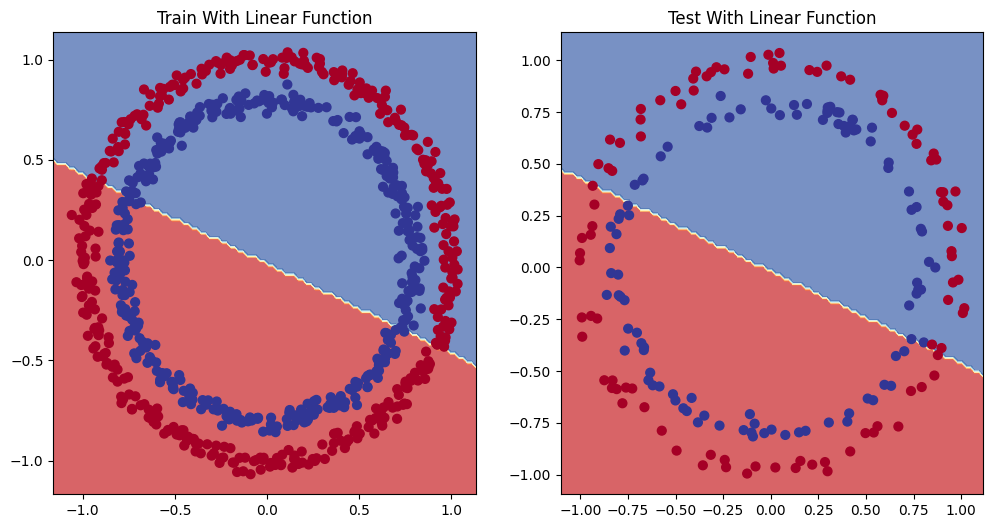

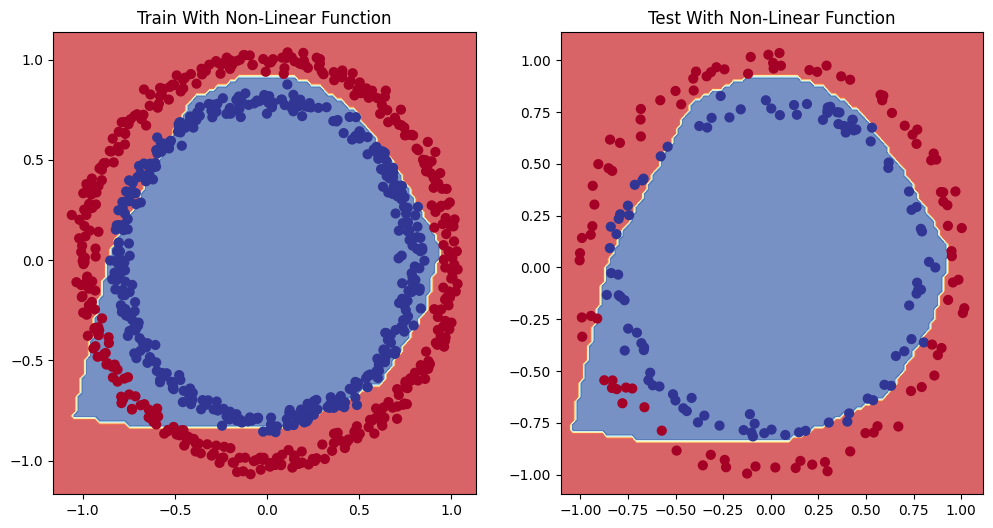

In [ ]:
# Plot decision boundaries
plt.figure(figsize=(12,6))
plt.subplot(1,2,1) # rows colum index format
plt.title("Train With Linear Function")
plot_decision_boundary(model_1,X_train,y_train)

plt.subplot(1,2,2)
plt.title("Test With Linear Function")
plot_decision_boundary(model_1,X_test,y_test)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1) # rows colum index format
plt.title("Train With Non-Linear Function")
plot_decision_boundary(model_3,X_train,y_train)

plt.subplot(1,2,2)
plt.title("Test With Non-Linear Function")
plot_decision_boundary(model_3,X_test,y_test)

### 6.3 Replicating non-linear activation functions
*Neural networks, rather than us telling the model what to learn, give it the tools to discover poatterns in data and it tries to figure out the patterns on its own*

In [ ]:
# Create a tensor
A = torch.arange(-10,10,1, dtype=torch.float32)
A


tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

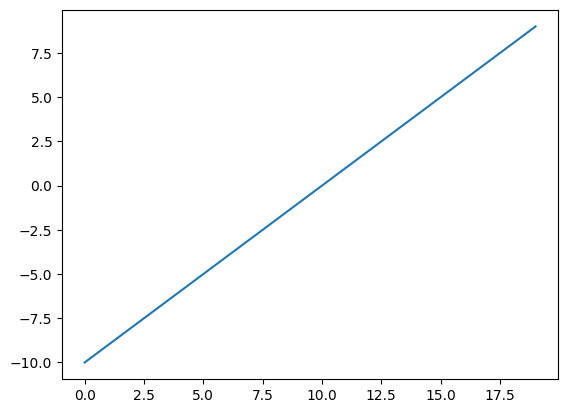

In [ ]:
# Visualize the tensor
plt.plot(A)

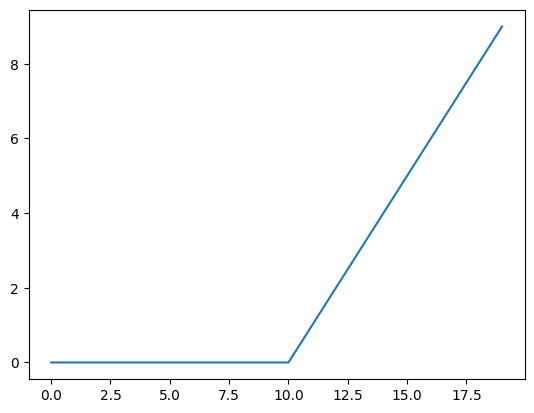

In [ ]:
plt.plot(torch.relu(A))

#### 6.3.1 Replicate `torch.relu()` function

In [ ]:
def relu(x: torch.Tensor) -> torch.Tensor:
  return torch.maximum(torch.tensor(0),x) # inputs must be tensors -> return non negative values

print(f"A tensor:\n{A}\nRelu tensor:\n{relu(A)}")

A tensor:
tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])
Relu tensor:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])


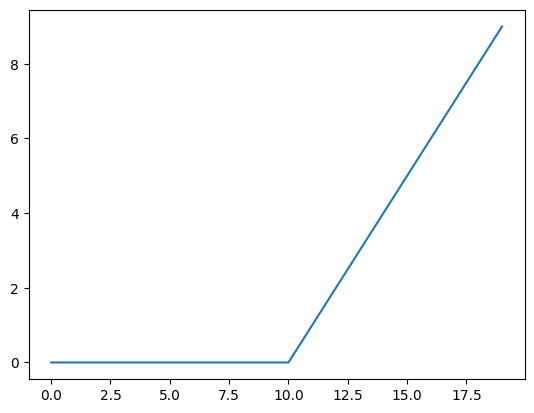

In [ ]:
# Plot our relu function
plt.plot(relu(A))

In [ ]:
# Let's do the same for Sigmoid

def sigmoid(x):
  return 1 / (1+torch.exp(-x))


print(f"A tensor:\n{A}\nSigmoid tensor:\n{sigmoid(A)}")


A tensor:
tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])
Sigmoid tensor:
tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])


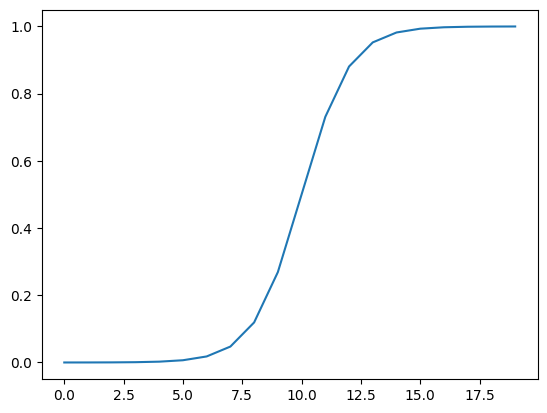

In [ ]:
# Plot torch.sigmoid
plt.plot(torch.sigmoid(A))

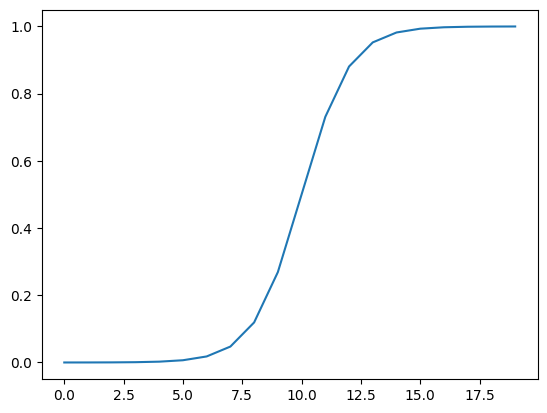

In [ ]:
# Plot our sigmoid function

plt.plot(sigmoid(A))

## 7.Putting it all together with a multi-class classification problem
* `Binary classification` - one thing or another(cat vs. dog,  fraud or not, etc)
* `Multi-class classification` -  more than one thing
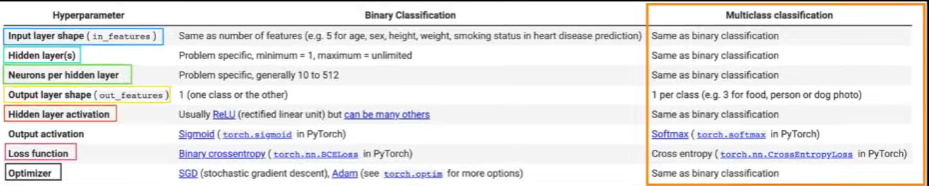

### 7.1 Create a toy multi-class dataset

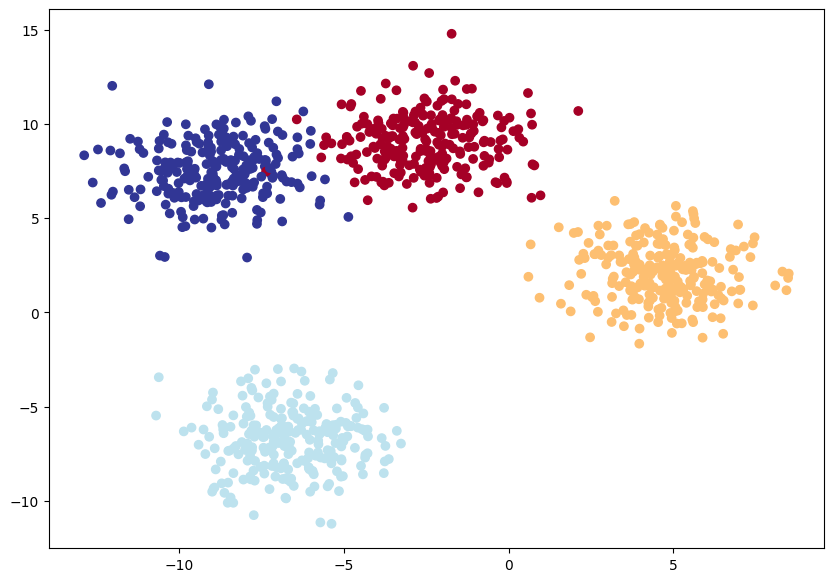

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
                           n_features=NUM_FEATURES,
                           centers=NUM_CLASSES,
                           cluster_std=1.5,
                           random_state=RANDOM_SEED)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

# 3. Split into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,y_blob,test_size=0.2, random_state=RANDOM_SEED)

# 4. Plot the data
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob,cmap=plt.cm.RdYlBu)







### 7.2 Building a multi-class classification model in PyTorch

In [ ]:
# Create device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
# Build a multi-class classification model
class BlobModel(nn.Module):
  def __init__(self,input_features,out_features,hidden_units=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=out_features)
    )

  def forward(self,x):
    return self.linear_layer_stack(x)


# Create an instance and set it to the target device
model_4 = BlobModel(input_features=2,out_features=4,hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

### 7.3 Create a loss function and an optimizer for a multi-class classification model

In [ ]:
# Create a loss function
loss_fn = nn.CrossEntropyLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model_4.parameters(),lr=0.1)



### 7.4 Getting prediction probabilities for multi-class model

In order to  evaluate and train and test our model, we need to convert our model's outputs(logits) to prediction probabilitites and then to prediction labels.

*Logits ***(raw output of th model)***-> Prediction probabilities ***(use softwmax activation function)*** -> Predicition labels ***(take the argmax of the prediction probabilities)****

In [ ]:
# Get raw outputs of our model (logits)
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test.to(device))

y_logits[:10]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]])

In [ ]:
y_blob_test[:10]

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0.])

In [ ]:
# Convert out model's logit outputs to prediction probabilities
y_pred_probs = torch.softmax(y_logits,dim=1)
print(f"Logits: {y_logits[:5]}")
print(f"Probabilities: {y_pred_probs[:5]}")

Logits: tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]])
Probabilities: tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]])


In [ ]:
torch.sum(y_pred_probs[0])

tensor(1.0000)

In [ ]:
torch.max(y_pred_probs[0])

tensor(0.3244)

In [ ]:
torch.argmax(y_pred_probs[0])

tensor(1)

In [ ]:
# Convert our model's prediction probabilities to prediction labels
y_preds = torch.argmax(y_pred_probs,dim=1)
y_preds[:10]

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### 7.5 Create a training and testing loop for a multi-class PyTorch model

In [ ]:
# Fit the multi-class model to the data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
epochs = 100

# Put the data to target device
X_blob_train, y_blob_tain = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

#Loop through data

for epoch in range(epochs):
### Training
  model_4.train()

  y_logits = model_4(X_blob_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_fn(y_logits,y_blob_train.type(torch.LongTensor))
  acc = accuracy_fn(y_true=y_blob_train,y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  # Testing
  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_blob_test)
    test_pred = torch.softmax(test_logits,dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits,y_blob_test.type(torch.LongTensor))
    test_acc = accuracy_fn(y_true=y_blob_test,y_pred=test_pred)

  # Print what's happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% |Test Loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.90937 | Acc: 67.62% |Test Loss: 0.88772 | Test acc: 74.50%
Epoch: 10 | Loss: 0.57521 | Acc: 97.88% |Test Loss: 0.58893 | Test acc: 98.50%
Epoch: 20 | Loss: 0.36964 | Acc: 99.00% |Test Loss: 0.37175 | Test acc: 100.00%
Epoch: 30 | Loss: 0.20275 | Acc: 99.25% |Test Loss: 0.19128 | Test acc: 99.50%
Epoch: 40 | Loss: 0.09166 | Acc: 99.25% |Test Loss: 0.08286 | Test acc: 99.50%
Epoch: 50 | Loss: 0.06013 | Acc: 99.25% |Test Loss: 0.05244 | Test acc: 99.50%
Epoch: 60 | Loss: 0.04785 | Acc: 99.25% |Test Loss: 0.04005 | Test acc: 99.50%
Epoch: 70 | Loss: 0.04138 | Acc: 99.25% |Test Loss: 0.03313 | Test acc: 99.50%
Epoch: 80 | Loss: 0.03729 | Acc: 99.25% |Test Loss: 0.02877 | Test acc: 99.50%
Epoch: 90 | Loss: 0.03454 | Acc: 99.25% |Test Loss: 0.02587 | Test acc: 99.50%


In [ ]:
# Make predictions with the model
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test)

# View first 10 raw predicitions
y_logits[:10]

tensor([[-0.6273,  6.0462, -7.6812, -8.5050],
        [-2.1954, -6.4160, -3.7504,  3.1709],
        [-3.4512, -3.9341,  3.1962, -2.6393],
        [-1.1606,  4.2403, -3.8749, -4.9132],
        [ 3.8042, -1.3354, -9.2017, -7.0059],
        [-2.8420, -7.6266, -4.3325,  3.8454],
        [-3.0664, -3.3663,  2.8296, -2.1611],
        [ 3.4181, -4.0582, -6.9469, -3.5824],
        [-4.4128, -5.0382,  3.8621, -3.4156],
        [ 3.5452, -3.0397, -7.5917, -4.7479]])

*Note: The values closest to one in `y_logits[:10]` is the index in our `y_pred_probs`*


---



In [ ]:
# Go from logits -> preidction probabilities
y_pred_probs = torch.softmax(y_logits,dim=1)
y_pred_probs[:10]

tensor([[1.2624e-03, 9.9874e-01, 1.0907e-06, 4.7857e-07],
        [4.6449e-03, 6.8231e-05, 9.8092e-04, 9.9431e-01],
        [1.2909e-03, 7.9649e-04, 9.9501e-01, 2.9074e-03],
        [4.4906e-03, 9.9511e-01, 2.9752e-04, 1.0533e-04],
        [9.9415e-01, 5.8260e-03, 2.2338e-06, 2.0076e-05],
        [1.2445e-03, 1.0401e-05, 2.8036e-04, 9.9846e-01],
        [2.7187e-03, 2.0144e-03, 9.8854e-01, 6.7224e-03],
        [9.9849e-01, 5.6549e-04, 3.1468e-05, 9.1004e-04],
        [2.5456e-04, 1.3620e-04, 9.9892e-01, 6.9004e-04],
        [9.9836e-01, 1.3788e-03, 1.4541e-05, 2.4983e-04]])

In [ ]:
# Go from predicition probs -> prediction labels
y_preds = torch.argmax(y_pred_probs,dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

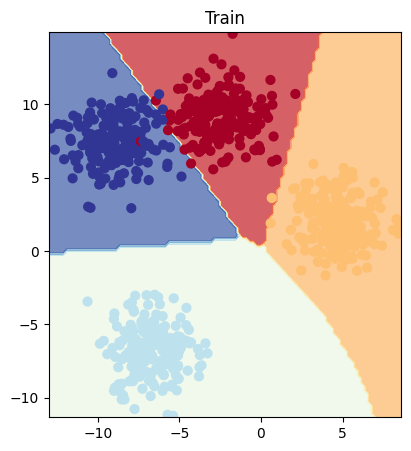

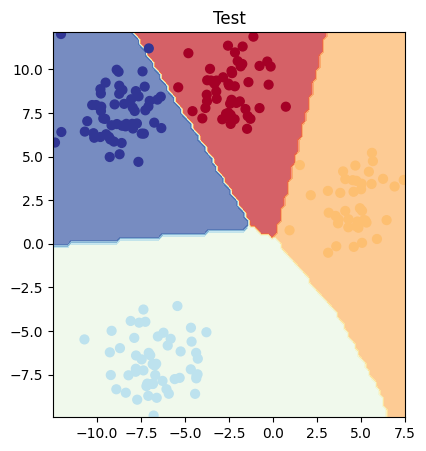

In [ ]:
#Visualize

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4,X_blob_train,y_blob_train)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Test")
plot_decision_boundary(model_4,X_blob_test,y_blob_test)



## 8.A few more classification metrics
* Accuracy - out ot 100 samples, how many our model get right
* Precision
* Recall
* F1-score
* Confusion matrix
* Classification report

*When to use precision/recall: https://medium.com/data-science/beyond-accuracy-precision-and-recall-3da06bea9f6c*


In [ ]:
!pip install torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 12.1 MB/s eta 0:00:00


In [ ]:
from torchmetrics import Accuracy

# Setup metric
torchmetrics_acc = Accuracy(task="multiclass",num_classes=4).to(device)

# Calculate accuracy
torchmetrics_acc(y_preds,y_blob_test)

tensor(0.9950)